# Olympics ML — Model Improvements & Comparisons

## Section 1 — Setup & Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/athlete_events.csv')
regions = pd.read_csv('../data/noc_regions.csv')

In [3]:
df = pd.merge(df, regions, on='NOC', how='left')

In [4]:
print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df.describe())

(271116, 17)
['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'region', 'notes']


<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
 15  region  270746 non-null  str    
 16  notes   5039 non-null    str    
dtypes: float64(3), int64(2), str(12)
memory usage: 35.2 MB
None
                  ID            Age         Height         Weight  \
count  271116.000000  261642.000000  210945.

In [5]:
df.drop(columns=['notes'], inplace=True)

In [6]:
df['Medal'] = df['Medal'].fillna('No Medal')

In [7]:
print(df['Medal'].value_counts())
print(df['Medal'].isnull().sum())

Medal
No Medal    231333
Gold         13372
Bronze       13295
Silver       13116
Name: count, dtype: int64
0


In [8]:
df['Medal_Won'] = df['Medal'].apply(lambda x: 0 if x == 'No Medal' else 1)

In [9]:
df['Age'] = df.groupby('Sport')['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [10]:
df['Height'] = df.groupby('Sport')['Height'].transform(
    lambda x: x.fillna(x.median())
)

In [11]:
df['Weight'] = df.groupby('Sport')['Weight'].transform(
    lambda x: x.fillna(x.median())
)

In [12]:
df.dropna(subset=['region'], inplace=True)

In [13]:
df['Height'] = df['Height'].fillna(df['Height'].median())
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

In [14]:
print("Shape after cleaning:", df.shape)
print("\nMissing values remaining:")
print(df.isnull().sum())
print("\nMedal_Won value counts:")
print(df['Medal_Won'].value_counts())

Shape after cleaning: (270746, 17)

Missing values remaining:
ID           0
Name         0
Sex          0
Age          0
Height       0
Weight       0
Team         0
NOC          0
Games        0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
region       0
Medal_Won    0
dtype: int64

Medal_Won value counts:
Medal_Won
0    230972
1     39774
Name: count, dtype: int64


In [15]:
cols = ['Sex','Age','Height','Weight','Year','Season','Sport','region','Medal_Won']
present = [c for c in cols if c in df.columns]
new_df = df[present].copy()
print("Selected columns:", present)

Selected columns: ['Sex', 'Age', 'Height', 'Weight', 'Year', 'Season', 'Sport', 'region', 'Medal_Won']


In [16]:
new_df.dropna(inplace=True)

In [18]:
from sklearn.preprocessing import LabelEncoder 

In [19]:
le_sex = LabelEncoder()
new_df['Sex'] = le_sex.fit_transform(new_df['Sex'])

In [20]:
le_season = LabelEncoder()
new_df['Season'] = le_season.fit_transform(new_df['Season'])

In [21]:
new_df = pd.get_dummies(new_df, columns=['Sport', 'region'], drop_first=True)

In [22]:
X = new_df.drop('Medal_Won', axis=1)
y = new_df['Medal_Won']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nMedal_Won value counts:")
print(y.value_counts())
print("\nData types in X:")
print(X.dtypes.value_counts())

X shape: (270746, 275)
y shape: (270746,)
X_train shape: (216596, 275)
X_test shape: (54150, 275)

Medal_Won value counts:
Medal_Won
0    230972
1     39774
Name: count, dtype: int64

Data types in X:
bool       269
int64        3
float64      3
Name: count, dtype: int64


In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
medal_le=RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
medal_le.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [27]:
y_pred = medal_le.predict(X_test)

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8535364727608495

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.91     46305
           1       0.50      0.64      0.56      7845

    accuracy                           0.85     54150
   macro avg       0.72      0.76      0.73     54150
weighted avg       0.87      0.85      0.86     54150


Confusion Matrix:
 [[41233  5072]
 [ 2859  4986]]


In [ ]:
# from sklearn.model_selection import cross_val_score
# estimator = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
# scores = cross_val_score(estimator, X, y , cv = 5, scoring='accuracy')

In [ ]:
# print("Scores for each fold:", scores)
# print("Average Score:", scores.mean())
# print("Standard Deviation:", scores.std())

Scores for each fold: [0.87355494 0.86514986 0.86430036 0.87039465 0.8604591 ]
Average Score: 0.8667717832095146
Standard Deviation: 0.004641656774184525


### Improvement 2 — ROC AUC Curve for Balanced RF

In [29]:
from sklearn.metrics import roc_auc_score, roc_curve

In [30]:
y_prob = medal_le.predict_proba(X_test)[:, 1]
y_prob

array([0.84198901, 0.08333333, 0.7148447 , ..., 0.05875   , 0.05      ,
       0.024     ], shape=(54150,))

In [31]:
auc_score=roc_auc_score(y_test,y_prob)
print(auc_score)

0.8651345413983778


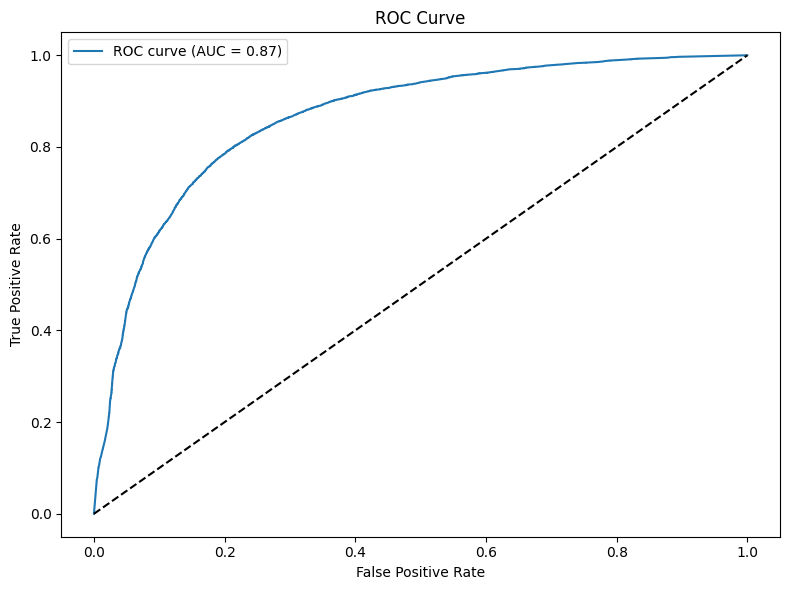

In [33]:
fp, tp, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fp, tp, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../graphs/roc_curve.png')
plt.show()

### Improvment 3 - XGBoost Classifier Comparision

In [38]:
# Install xgboost into the current Jupyter kernel (run once) and import
import importlib.util
if importlib.util.find_spec("xgboost") is None:
    %pip install xgboost
from xgboost import XGBClassifier


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


c:\Users\DELL\Desktop\ML-projects\Olympics-data-analysis\venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=4>
  res = process_handler(cmd, _system_body)
c:\Users\DELL\Desktop\ML-projects\Olympics-data-analysis\venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)
c:\Users\DELL\Desktop\ML-projects\Olympics-data-analysis\venv\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)


Note: you may need to restart the kernel to use updated packages.


In [39]:
xgb_model = XGBClassifier(n_estimators=100, scale_pos_weight=6,random_state=42, use_label_encoder=False, eval_metric="logloss")

In [40]:
xgb_model.fit(X_train, y_train)

c:\Users\DELL\Desktop\ML-projects\Olympics-data-analysis\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:40:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [41]:
y_pred_xgb = xgb_model.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7491228070175439

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.75      0.84     46305
           1       0.34      0.77      0.47      7845

    accuracy                           0.75     54150
   macro avg       0.65      0.76      0.65     54150
weighted avg       0.86      0.75      0.78     54150


Confusion Matrix:
 [[34507 11798]
 [ 1787  6058]]


In [43]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_score_xgb=roc_auc_score(y_test,y_prob_xgb)
print(auc_score_xgb)

0.8376455484112773


In [44]:
import pickle
pickle.dump(medal_le, open("../models/balanced_medal_model.pkl", "wb"))

C:\Users\DELL\AppData\Local\Temp\ipykernel_2532\2909811152.py:2: ResourceWarning: unclosed file <_io.BufferedWriter name='../models/balanced_medal_model.pkl'>
  pickle.dump(medal_le, open("../models/balanced_medal_model.pkl", "wb"))
